# Phase 3: Robustness-First Pipeline

**Objective**: Determine whether any tradeable edge exists in 1-hour crypto bars after
fixing the three root causes identified in Phase 2:

1. **Label noise** — Phase 2 used raw 1-bar forward returns.  Here we use
   ATR-normalised returns so a 0.5% move is judged relative to current volatility,
   not in absolute dollar terms.

2. **Weak features** — Phase 2 had only lagged returns + volume z-score.
   Here we add regime features (volatility level, trend direction) and
   cross-asset relative strength.

3. **Overfit evaluation harness** — Phase 2 used one 80/20 split; a single lucky
   test window masked instability.  Here we use walk-forward cross-validation
   with 4 non-overlapping test windows.

**Kill criterion**: If median OOS Sharpe ≤ 0 across folds on ≥ 2 of 3 symbols,
we conclude there is no reliable edge and halt further live-deployment planning.

## 1. Setup

Imports, credentials, and constants.

In [1]:
import sys
import os

# Ensure the repo root is on sys.path when running from notebooks/
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

In [2]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from bot.backtest.engine import apply_signal_policy, run_backtest
from bot.backtest.metrics import (
    compute_calibration_metrics,
    compute_metrics,
    compute_walkforward_summary,
)
from bot.backtest.walkforward import run_walkforward
from bot.config import (
    ABSTAIN_HI,
    ABSTAIN_LO,
    HISTORY_MONTHS,
    MIN_HOLD_BARS,
    WALKFORWARD_N_FOLDS,
    WALKFORWARD_TEST_BARS,
    WALKFORWARD_TRAIN_BARS,
    WALKFORWARD_VAL_BARS,
)
from bot.data.fetcher import fetch_bars_range
from bot.features.labeling import make_labels, make_vol_adjusted_labels
from bot.features.regime import compute_cross_asset_features
from bot.features.rolling import compute_features
from bot.utils.credentials import load_credentials

In [3]:
# ── Credentials ──────────────────────────────────────────────────────────────
api_key, secret_key = load_credentials()

# ── Experiment constants ──────────────────────────────────────────────────────
# Symbols to evaluate (reference symbol first — walk-forward runs on each)
SYMBOLS = ["BTC/USD", "ETH/USD", "SOL/USD"]
REF_SYMBOL = "BTC/USD"

# Walk-forward fold geometry (from config; shown here for reference)
print("Walk-forward fold geometry:")
print(f"  train_bars = {WALKFORWARD_TRAIN_BARS}  (~{WALKFORWARD_TRAIN_BARS/24:.0f} days)")
print(f"  val_bars   = {WALKFORWARD_VAL_BARS}   (~{WALKFORWARD_VAL_BARS/24:.0f} days)")
print(f"  test_bars  = {WALKFORWARD_TEST_BARS}   (~{WALKFORWARD_TEST_BARS/24:.0f} days)")
print(f"  n_folds    = {WALKFORWARD_N_FOLDS}")
print(f"\nMinimum bars needed: {WALKFORWARD_TRAIN_BARS + WALKFORWARD_VAL_BARS + WALKFORWARD_TEST_BARS}")
print(f"\nSignal policy: abstain_lo={ABSTAIN_LO}, abstain_hi={ABSTAIN_HI}, min_hold={MIN_HOLD_BARS}")

Credentials loaded.
Walk-forward fold geometry:
  train_bars = 1800  (~75 days)
  val_bars   = 600   (~25 days)
  test_bars  = 600   (~25 days)
  n_folds    = 4

Minimum bars needed: 3000

Signal policy: abstain_lo=0.45, abstain_hi=0.55, min_hold=1


## 2. Data (Multi-Symbol)

Fetch 6 months of hourly OHLCV bars for BTC, ETH, and SOL, then compute
cross-asset relative-strength features.

In [4]:
# ── Fetch raw bars for each symbol ───────────────────────────────────────────
print("Fetching bars...")
raw_bars = {}
for sym in SYMBOLS:
    df_sym = fetch_bars_range(api_key, secret_key, symbol=sym)

    # fetch_bars_range returns a "timestamp" column; convert it to DatetimeIndex
    # so downstream code and date-range printing are consistent.
    if "timestamp" in df_sym.columns:
        df_sym = df_sym.set_index("timestamp")

    raw_bars[sym] = df_sym
    print(f"  {sym}: {len(df_sym)} bars  "
          f"({df_sym.index[0].date()} → {df_sym.index[-1].date()})")

Fetching bars...
  BTC/USD: 4319 bars  (2025-10-21 → 2026-04-19)
  ETH/USD: 4318 bars  (2025-10-21 → 2026-04-19)
  SOL/USD: 4319 bars  (2025-10-21 → 2026-04-19)


In [5]:
# ── Compute base + extended features for each symbol ─────────────────────────
# We compute features first (gives us the 'return' column) before calling
# compute_cross_asset_features, which needs the 'return' column.
feat_bars = {}
for sym in SYMBOLS:
    feat_bars[sym] = compute_features(raw_bars[sym], extended=True)
    print(f"  {sym}: {len(feat_bars[sym])} bars after feature warm-up")

  BTC/USD: 4300 bars after feature warm-up
  ETH/USD: 4299 bars after feature warm-up
  SOL/USD: 4300 bars after feature warm-up


In [6]:
# ── Cross-asset relative-strength features ────────────────────────────────────
# Adds columns like btc_excess_return_vs_eth, btc_excess_return_vs_sol to the
# BTC/USD DataFrame.  Only rows present in ALL three symbols are kept.
#
# These features capture: "has BTC been outperforming or underperforming its peers?"
# Cross-asset divergences sometimes precede trend reversals.
df_btc_cross = compute_cross_asset_features(feat_bars, ref_symbol=REF_SYMBOL)

print(f"BTC with cross-asset features: {len(df_btc_cross)} bars")
cross_cols = [c for c in df_btc_cross.columns if "excess_return" in c]
print(f"Cross-asset columns: {cross_cols}")
df_btc_cross[cross_cols].describe()

BTC with cross-asset features: 4288 bars
Cross-asset columns: ['btc_excess_return_vs_eth', 'btc_excess_return_vs_sol']


,btc_excess_return_vs_eth,btc_excess_return_vs_sol
count,4288.000000,4288.000000
mean,0.000248,0.000944
std,0.013933,0.014187
min,-0.056377,-0.070660
25%,-0.006893,-0.006656
50%,0.000045,0.001062
75%,0.007606,0.008267
max,0.069675,0.078834


## 3. Regime Features

Add three market-state features to BTC/USD:
- `vol_percentile`: is the market calm (0), normal (1), or turbulent (2)?
- `trend_slope`: is price trending up, flat, or down?
- `atr_normalized_return`: was this bar's return large or small for this market?

In [7]:
# compute_features with regime=True appends the three regime columns
df_btc_regime = compute_features(raw_bars[REF_SYMBOL], extended=True, regime=True)

regime_cols = ["vol_percentile", "trend_slope", "atr_normalized_return"]
print(f"Total feature columns: {len(df_btc_regime.columns)}")
print(f"Regime feature columns: {regime_cols}")
df_btc_regime[regime_cols].describe()

Total feature columns: 17
Regime feature columns: ['vol_percentile', 'trend_slope', 'atr_normalized_return']


,vol_percentile,trend_slope,atr_normalized_return
count,4049.000000,4049.000000,4.049000e+03
mean,0.969869,-0.006044,-2.087111e-07
std,0.823974,0.108332,1.752656e-05
min,0.000000,-0.411666,-1.164731e-04
25%,0.000000,-0.102492,-9.451208e-06
50%,1.000000,-0.011751,-2.067568e-07
75%,2.000000,0.093915,9.254365e-06
max,2.000000,0.328237,8.492011e-05


In [8]:
# ── Distribution of volatility regime labels ──────────────────────────────────
# Shows what fraction of bars fall into each regime bucket.
# We'd expect roughly 33% in each if the bucketing is working correctly.
vol_dist = df_btc_regime["vol_percentile"].value_counts(normalize=True).sort_index()
print("Volatility regime distribution:")
print(f"  0 (low vol):  {vol_dist.get(0, 0):.1%}")
print(f"  1 (medium):   {vol_dist.get(1, 0):.1%}")
print(f"  2 (high vol): {vol_dist.get(2, 0):.1%}")

Volatility regime distribution:
  0 (low vol):  35.5%
  1 (medium):   32.0%
  2 (high vol): 32.5%


## 4. Walk-Forward: Baseline (Vol-Adjusted Labels Only)

Run walk-forward on BTC/USD using:
- Extended features only (no regime features)
- Vol-adjusted labels (ATR-normalised forward returns)
- Abstain-band signal policy

This establishes a baseline that we compare against in Section 5.

In [9]:
# ── Define callable functions for the walk-forward harness ───────────────────

def feature_fn_base(df_raw):
    """Compute 9 base+extended features (no regime features)."""
    return compute_features(df_raw, extended=True, regime=False)


def label_fn_vol(df_feat, compute_thresholds=False, lower=None, upper=None):
    """ATR-normalised binary labels."""
    return make_vol_adjusted_labels(
        df_feat,
        lower=lower,
        upper=upper,
        compute_thresholds=compute_thresholds,
    )


def model_fn(X_train, y_train):
    """Train a logistic regression model with 5-fold time-series CV."""
    tscv = TimeSeriesSplit(n_splits=5)
    # C controls regularisation strength: small C = simple model, large C = complex.
    # We search over a range to avoid both underfitting and overfitting.
    grid = GridSearchCV(
        LogisticRegression(max_iter=1000, solver="lbfgs", random_state=42),
        {"C": [0.01, 0.1, 1.0, 10.0]},
        cv=tscv,
        scoring="f1",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    return grid.best_estimator_


def policy_fn(prob_series):
    """Abstain-band policy with default thresholds from config."""
    return apply_signal_policy(
        prob_series,
        abstain_lo=ABSTAIN_LO,
        abstain_hi=ABSTAIN_HI,
        min_hold_bars=MIN_HOLD_BARS,
    )

print("Callable functions defined.")

Callable functions defined.


In [10]:
# ── Run walk-forward: BTC, vol-adjusted labels, base features ─────────────────
print(f"Running walk-forward on {REF_SYMBOL} (base features + vol labels)...")
print(f"  {WALKFORWARD_N_FOLDS} folds × {WALKFORWARD_TRAIN_BARS}/{WALKFORWARD_VAL_BARS}/{WALKFORWARD_TEST_BARS} train/val/test bars")

folds_base_btc = run_walkforward(
    raw_bars[REF_SYMBOL],
    n_folds=WALKFORWARD_N_FOLDS,
    train_bars=WALKFORWARD_TRAIN_BARS,
    val_bars=WALKFORWARD_VAL_BARS,
    test_bars=WALKFORWARD_TEST_BARS,
    feature_fn=feature_fn_base,
    label_fn=label_fn_vol,
    model_fn=model_fn,
    policy_fn=policy_fn,
)

print(f"\nCompleted {len(folds_base_btc)} fold(s).")

Running walk-forward on BTC/USD (base features + vol labels)...
  4 folds × 1800/600/600 train/val/test bars

Completed 4 fold(s).


/tmp/ipykernel_71558/3727323002.py:5: UserWarning: Walk-forward fold 4 failed and will be skipped: Not enough bars for fold 4: need 4800, have 4319.  Reduce n_folds or bar counts in config.
  folds_base_btc = run_walkforward(


In [11]:
# ── Display per-fold results ──────────────────────────────────────────────────
df_folds_base = pd.DataFrame(folds_base_btc)

# Format for display
disp = df_folds_base.copy()
for col in ["total_return", "max_drawdown", "win_rate"]:
    if col in disp.columns:
        disp[col] = disp[col].map(lambda x: f"{x:.2%}" if x is not None else "—")
for col in ["sharpe_ratio", "brier_score"]:
    if col in disp.columns:
        disp[col] = disp[col].map(lambda x: f"{x:.4f}" if x is not None else "—")

print(f"\n{REF_SYMBOL} — Walk-Forward (base features + vol-adjusted labels)")
print("=" * 80)
disp[["fold", "test_start", "test_end", "total_return",
      "sharpe_ratio", "max_drawdown", "num_trades", "win_rate", "brier_score"]]


BTC/USD — Walk-Forward (base features + vol-adjusted labels)


,fold,test_start,test_end,total_return,sharpe_ratio,max_drawdown,num_trades,win_rate,brier_score
0,1,2026-01-29 10:00:00+00:00,2026-02-23 09:00:00+00:00,-31.68%,-13.4915,-32.45%,48.0,33.33%,0.2536
1,2,2026-02-23 10:00:00+00:00,2026-03-20 10:00:00+00:00,11.72%,3.3702,-10.53%,1.0,100.00%,0.3588
2,3,2026-03-20 11:00:00+00:00,2026-04-14 10:00:00+00:00,-15.91%,-11.0161,-16.12%,60.0,36.67%,0.2501
3,4,NaT,NaT,nan%,nan,nan%,NaN,nan%,nan


## 5. Walk-Forward: Regime Features

Re-run the walk-forward adding the three regime features (vol_percentile,
trend_slope, atr_normalized_return) to the feature set.  We compare against
Section 4 to see whether regime context actually helps the model.

In [12]:
def feature_fn_regime(df_raw):
    """Compute 9 base+extended features PLUS 3 regime features (12 total)."""
    return compute_features(df_raw, extended=True, regime=True)


print(f"Running walk-forward on {REF_SYMBOL} (regime features + vol labels)...")

folds_regime_btc = run_walkforward(
    raw_bars[REF_SYMBOL],
    n_folds=WALKFORWARD_N_FOLDS,
    train_bars=WALKFORWARD_TRAIN_BARS,
    val_bars=WALKFORWARD_VAL_BARS,
    test_bars=WALKFORWARD_TEST_BARS,
    feature_fn=feature_fn_regime,
    label_fn=label_fn_vol,
    model_fn=model_fn,
    policy_fn=policy_fn,
)

print(f"Completed {len(folds_regime_btc)} fold(s).")

Running walk-forward on BTC/USD (regime features + vol labels)...
Completed 4 fold(s).


/tmp/ipykernel_71558/1844752406.py:8: UserWarning: Walk-forward fold 4 failed and will be skipped: Not enough bars for fold 4: need 4800, have 4319.  Reduce n_folds or bar counts in config.
  folds_regime_btc = run_walkforward(


In [13]:
# ── Side-by-side comparison: base features vs. regime features ────────────────
base_sharpes   = [f["sharpe_ratio"]  for f in folds_base_btc   if f["sharpe_ratio"]  is not None]
regime_sharpes = [f["sharpe_ratio"]  for f in folds_regime_btc if f["sharpe_ratio"]  is not None]

print("Per-fold Sharpe comparison (BTC/USD):")
print(f"{'Fold':<6} {'Base':>10} {'+ Regime':>10} {'Delta':>10}")
print("-" * 38)
for i, (b, r) in enumerate(zip(base_sharpes, regime_sharpes), 1):
    delta = r - b
    arrow = "▲" if delta > 0 else "▼"
    print(f"{i:<6} {b:>10.4f} {r:>10.4f} {arrow}{abs(delta):>9.4f}")

if base_sharpes and regime_sharpes:
    import statistics
    print(f"\nMedian Sharpe  base={statistics.median(base_sharpes):.4f}  "
          f"regime={statistics.median(regime_sharpes):.4f}")

Per-fold Sharpe comparison (BTC/USD):
Fold         Base   + Regime      Delta
--------------------------------------
1        -13.4915    -2.6719 ▲  10.8196
2          3.3702     1.9399 ▼   1.4303
3        -11.0161    -9.5559 ▲   1.4602

Median Sharpe  base=-11.0161  regime=-2.6719


## 5b. Walk-Forward: All Three Symbols

Run walk-forward on ETH/USD and SOL/USD (using regime features) to assess
whether results generalise beyond BTC.

In [14]:
# Store results keyed by symbol for the kill-criterion evaluation
all_folds = {REF_SYMBOL: folds_regime_btc}

for sym in [s for s in SYMBOLS if s != REF_SYMBOL]:
    print(f"Running walk-forward on {sym}...")
    folds = run_walkforward(
        raw_bars[sym],
        n_folds=WALKFORWARD_N_FOLDS,
        train_bars=WALKFORWARD_TRAIN_BARS,
        val_bars=WALKFORWARD_VAL_BARS,
        test_bars=WALKFORWARD_TEST_BARS,
        feature_fn=feature_fn_regime,
        label_fn=label_fn_vol,
        model_fn=model_fn,
        policy_fn=policy_fn,
    )
    all_folds[sym] = folds
    print(f"  → {len([f for f in folds if f['sharpe_ratio'] is not None])} valid folds")

print("\nAll symbols complete.")

Running walk-forward on ETH/USD...


/tmp/ipykernel_71558/2592869975.py:6: UserWarning: Walk-forward fold 4 failed and will be skipped: Not enough bars for fold 4: need 4800, have 4318.  Reduce n_folds or bar counts in config.
  folds = run_walkforward(


  → 3 valid folds
Running walk-forward on SOL/USD...
  → 3 valid folds

All symbols complete.


/tmp/ipykernel_71558/2592869975.py:6: UserWarning: Walk-forward fold 4 failed and will be skipped: Not enough bars for fold 4: need 4800, have 4319.  Reduce n_folds or bar counts in config.
  folds = run_walkforward(


## 6. Walk-Forward Summary

Aggregate each symbol's fold results into summary statistics.

In [15]:
# ── Per-symbol summary table ──────────────────────────────────────────────────
summaries = {}
for sym, folds in all_folds.items():
    summaries[sym] = compute_walkforward_summary(folds)

summary_rows = []
for sym, s in summaries.items():
    summary_rows.append({
        "symbol":              sym,
        "n_folds":             s["n_folds"],
        "median_sharpe":       f"{s['median_sharpe']:.4f}" if s["median_sharpe"] is not None else "—",
        "std_sharpe":          f"{s['std_sharpe']:.4f}"    if s["std_sharpe"]    is not None else "—",
        "best_sharpe":         f"{s['best_sharpe']:.4f}"   if s["best_sharpe"]   is not None else "—",
        "worst_sharpe":        f"{s['worst_sharpe']:.4f}"  if s["worst_sharpe"]  is not None else "—",
        "median_total_return": f"{s['median_total_return']:.2%}" if s["median_total_return"] is not None else "—",
        "median_max_drawdown": f"{s['median_max_drawdown']:.2%}" if s["median_max_drawdown"] is not None else "—",
    })

df_summary = pd.DataFrame(summary_rows).set_index("symbol")
print("Walk-Forward Summary (regime features + vol-adjusted labels)")
print("=" * 80)
df_summary

Walk-Forward Summary (regime features + vol-adjusted labels)


,n_folds,median_sharpe,std_sharpe,best_sharpe,worst_sharpe,median_total_return,median_max_drawdown
symbol,,,,,,,
BTC/USD,3,-2.6719,5.7852,1.9399,-9.5559,-5.07%,-8.39%
ETH/USD,3,-4.4320,8.2721,4.1192,-12.4219,-6.80%,-10.50%
SOL/USD,3,-2.3516,5.1854,2.7597,-7.6107,-2.24%,-9.10%


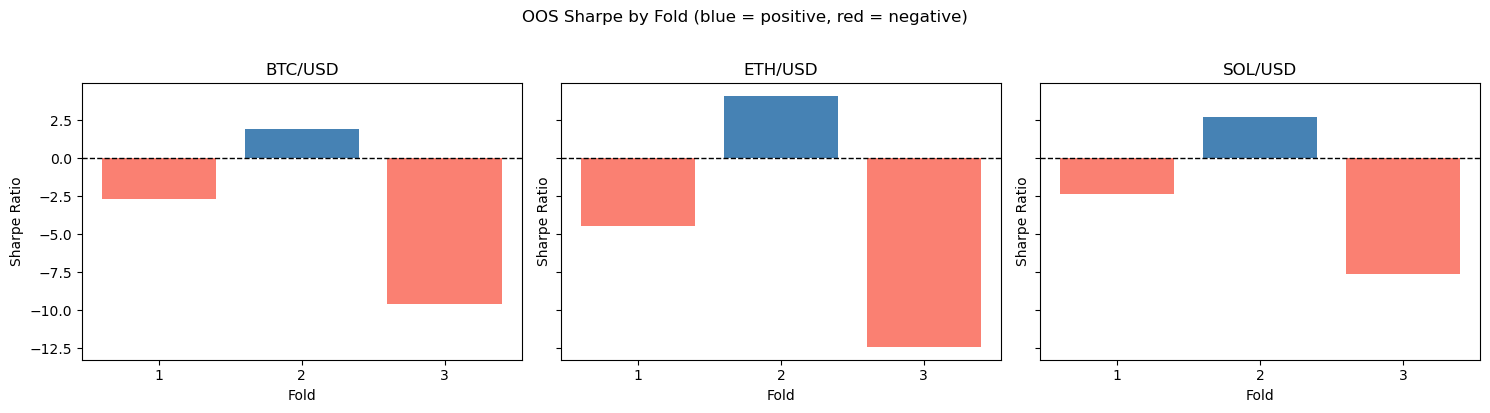

In [16]:
# ── Sharpe distribution chart ─────────────────────────────────────────────────
# Each bar = one fold's Sharpe ratio; horizontal line at 0 is the break-even level.
# A strategy with real edge should have most bars above 0.
fig, axes = plt.subplots(1, len(all_folds), figsize=(5 * len(all_folds), 4), sharey=True)
if len(all_folds) == 1:
    axes = [axes]

for ax, (sym, folds) in zip(axes, all_folds.items()):
    sharpes = [f["sharpe_ratio"] for f in folds if f["sharpe_ratio"] is not None]
    fold_nums = [f["fold"] for f in folds if f["sharpe_ratio"] is not None]
    colors = ["steelblue" if s > 0 else "salmon" for s in sharpes]
    ax.bar(fold_nums, sharpes, color=colors)
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(sym)
    ax.set_xlabel("Fold")
    ax.set_ylabel("Sharpe Ratio")
    ax.set_xticks(fold_nums)

fig.suptitle("OOS Sharpe by Fold (blue = positive, red = negative)", y=1.02)
plt.tight_layout()
plt.show()

## 7. Calibration Diagnostics

Brier score and reliability diagram for BTC/USD test folds.

A low Brier score means the model's probability estimates are close to
reality.  The reliability diagram shows whether stated confidence levels
match actual outcome frequencies.

In [17]:
# ── Collect calibration data by re-running inference on the last valid fold ───
# (For a full calibration analysis, pool all test-fold predictions.)

btc_folds = all_folds[REF_SYMBOL]
valid_btc_folds = [f for f in btc_folds if f["brier_score"] is not None]

if valid_btc_folds:
    brier_scores = [f["brier_score"] for f in valid_btc_folds]
    print(f"Brier scores across {len(brier_scores)} fold(s):")
    for fold in valid_btc_folds:
        print(f"  Fold {fold['fold']}: {fold['brier_score']:.4f}")
    print(f"\nMedian Brier score: {pd.Series(brier_scores).median():.4f}")
    print("(Random guessing at 0.5 on a balanced dataset ≈ 0.25; lower is better)")
else:
    print("No valid fold brier scores available.")

Brier scores across 3 fold(s):
  Fold 1: 0.2713
  Fold 2: 0.3396
  Fold 3: 0.2481

Median Brier score: 0.2713
(Random guessing at 0.5 on a balanced dataset ≈ 0.25; lower is better)


In [18]:
# ── Reliability diagram from the last fold's stored calibration bins ───────────
# Re-run the last fold manually to obtain calibration bins for plotting.

# Identify the last fold boundary
last_fold_idx = WALKFORWARD_N_FOLDS - 1
train_start = last_fold_idx * WALKFORWARD_TEST_BARS
train_end   = train_start + WALKFORWARD_TRAIN_BARS
val_end     = train_end   + WALKFORWARD_VAL_BARS
test_end    = val_end     + WALKFORWARD_TEST_BARS

df_ref = raw_bars[REF_SYMBOL]

if test_end <= len(df_ref):
    df_tr  = compute_features(df_ref.iloc[train_start:train_end].copy(), extended=True, regime=True)
    df_te  = compute_features(df_ref.iloc[val_end:test_end].copy(),      extended=True, regime=True)

    X_tr, y_tr, lo, hi = make_vol_adjusted_labels(df_tr, compute_thresholds=True)
    X_te, y_te         = make_vol_adjusted_labels(df_te, lower=lo, upper=hi)

    last_model = model_fn(X_tr, y_tr)
    feat_cols  = X_tr.columns.tolist()
    probs      = pd.Series(
        last_model.predict_proba(df_te[feat_cols])[:, 1],
        index=df_te.index,
    )

    # Align probabilities to labeled rows for calibration
    probs_labeled = probs.iloc[y_te.index].reset_index(drop=True)
    y_te_aligned  = y_te.reset_index(drop=True)

    cal_data = compute_calibration_metrics(y_te_aligned, probs_labeled)

    # ── Reliability diagram ───────────────────────────────────────────────────
    # X-axis: what probability did the model predict?
    # Y-axis: what fraction of those bars were actually long?
    # Diagonal line = perfect calibration.
    bins   = cal_data["calibration_bins"]
    if bins:
        mean_pred = [v["mean_predicted_prob"] for v in bins.values()]
        frac_pos  = [v["fraction_positive"]   for v in bins.values()]

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
        ax.scatter(mean_pred, frac_pos, s=60, color="steelblue", zorder=5,
                   label="Model")
        ax.plot(mean_pred, frac_pos, color="steelblue", alpha=0.6)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Mean Predicted Probability")
        ax.set_ylabel("Fraction of Positives (Actual)")
        ax.set_title(f"{REF_SYMBOL} — Reliability Diagram (last fold)\n"
                     f"Brier score: {cal_data['brier_score']:.4f}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough data for calibration bins.")
else:
    print(f"Not enough bars for last fold (need {test_end}, have {len(df_ref)}).")

Not enough bars for last fold (need 4800, have 4319).


## 8. Kill Criterion Evaluation

**Gate**: median OOS Sharpe > 0 across all folds AND across ≥ 2 of 3 symbols.

- **PASS** → the strategy shows a consistent positive edge; proceed to
  Phase 4 (live paper trading with position sizing).
- **FAIL** → the strategy has no reliable edge at this time frame/feature set;
  do not proceed to live trading.

In [19]:
# ── Kill criterion evaluation ─────────────────────────────────────────────────
print("=" * 60)
print("PHASE 3 KILL CRITERION EVALUATION")
print("=" * 60)
print("Gate: median OOS Sharpe > 0 on ≥ 2 of 3 symbols")
print()

symbol_results = {}
for sym, folds in all_folds.items():
    summary = compute_walkforward_summary(folds)
    med_sharpe = summary["median_sharpe"]
    passes = med_sharpe is not None and med_sharpe > 0
    symbol_results[sym] = {
        "median_sharpe": med_sharpe,
        "n_valid_folds": summary["n_folds"],
        "passes": passes,
    }
    status = "PASS ✓" if passes else "FAIL ✗"
    sharpe_str = f"{med_sharpe:.4f}" if med_sharpe is not None else "N/A"
    print(f"  {sym:<12} median Sharpe = {sharpe_str:>8}  "
          f"(n_folds={summary['n_folds']})  → {status}")

print()
passing_symbols = [sym for sym, r in symbol_results.items() if r["passes"]]
n_passing = len(passing_symbols)

print(f"Symbols passing: {n_passing}/3  ({', '.join(passing_symbols) if passing_symbols else 'none'})")
print()

if n_passing >= 2:
    print("RESULT: ✅ PASS")
    print()
    print("The strategy shows a positive median OOS Sharpe ratio on "
          f"{n_passing} of 3 symbols.")
    print("Recommendation: proceed to Phase 4 (paper trading with position sizing).")
else:
    print("RESULT: ❌ FAIL")
    print()
    print(f"Only {n_passing} of 3 symbols passed the Sharpe gate.")
    print("The strategy does not demonstrate a reliable edge on hourly crypto bars")
    print("with the current feature set and labeling scheme.")
    print()
    print("Phase 3 conclusion: no further live-deployment planning at this time.")
    print("Potential next steps if you want to continue:")
    print("  1. Try a different time frame (e.g., 4-hour or daily bars)")
    print("  2. Explore alternative model classes (XGBoost, LSTM)")
    print("  3. Investigate alternative labeling horizons (e.g., 6-bar forward)")

print()
print("=" * 60)

PHASE 3 KILL CRITERION EVALUATION
Gate: median OOS Sharpe > 0 on ≥ 2 of 3 symbols

  BTC/USD      median Sharpe =  -2.6719  (n_folds=3)  → FAIL ✗
  ETH/USD      median Sharpe =  -4.4320  (n_folds=3)  → FAIL ✗
  SOL/USD      median Sharpe =  -2.3516  (n_folds=3)  → FAIL ✗

Symbols passing: 0/3  (none)

RESULT: ❌ FAIL

Only 0 of 3 symbols passed the Sharpe gate.
The strategy does not demonstrate a reliable edge on hourly crypto bars
with the current feature set and labeling scheme.

Phase 3 conclusion: no further live-deployment planning at this time.
Potential next steps if you want to continue:
  1. Try a different time frame (e.g., 4-hour or daily bars)
  2. Explore alternative model classes (XGBoost, LSTM)
  3. Investigate alternative labeling horizons (e.g., 6-bar forward)



In [20]:

import statistics as _st

# ── Vol regime distribution ───────────────────────────────────────────────────
print("=== Volatility Regime Distribution (BTC) ===")
for k in [0, 1, 2]:
    print(f"  {k}: {vol_dist.get(k, 0):.1%}")

# ── Base walk-forward results ─────────────────────────────────────────────────
print("\n=== BTC Walk-Forward: Base Features ===")
for f in folds_base_btc:
    sr = f"sharpe={f['sharpe_ratio']:.4f}" if f['sharpe_ratio'] is not None else "sharpe=None"
    tr = f"ret={f['total_return']:.2%}" if f['total_return'] is not None else "ret=None"
    nt = f"trades={f['num_trades']}" if f['num_trades'] is not None else "trades=None"
    print(f"  Fold {f['fold']}: {sr}  {tr}  {nt}")
valid_base = [f['sharpe_ratio'] for f in folds_base_btc if f['sharpe_ratio'] is not None]
if valid_base: print(f"  → median Sharpe: {_st.median(valid_base):.4f}")

# ── Regime walk-forward results ───────────────────────────────────────────────
print("\n=== Walk-Forward Results (Regime Features) ===")
for sym, folds in all_folds.items():
    print(f"\n  {sym}:")
    for f in folds:
        sr = f"sharpe={f['sharpe_ratio']:.4f}" if f['sharpe_ratio'] is not None else "sharpe=SKIP"
        tr = f"ret={f['total_return']:.2%}" if f['total_return'] is not None else "ret=SKIP"
        bs = f"brier={f['brier_score']:.4f}" if f['brier_score'] is not None else "brier=SKIP"
        print(f"    Fold {f['fold']}: {sr}  {tr}  {bs}")
    valid = [f['sharpe_ratio'] for f in folds if f['sharpe_ratio'] is not None]
    if valid: print(f"    → median Sharpe: {_st.median(valid):.4f}")

# ── Kill criterion ────────────────────────────────────────────────────────────
print("\n=== Kill Criterion ===")
print(f"  Passing symbols ({n_passing}/3): {passing_symbols}")
print(f"  Result: {'PASS' if n_passing >= 2 else 'FAIL'}")


=== Volatility Regime Distribution (BTC) ===
  0: 35.5%
  1: 32.0%
  2: 32.5%

=== BTC Walk-Forward: Base Features ===
  Fold 1: sharpe=-13.4915  ret=-31.68%  trades=48
  Fold 2: sharpe=3.3702  ret=11.72%  trades=1
  Fold 3: sharpe=-11.0161  ret=-15.91%  trades=60
  Fold 4: sharpe=None  ret=None  trades=None
  → median Sharpe: -11.0161

=== Walk-Forward Results (Regime Features) ===

  BTC/USD:
    Fold 1: sharpe=-2.6719  ret=-5.40%  brier=0.2713
    Fold 2: sharpe=1.9399  ret=2.99%  brier=0.3396
    Fold 3: sharpe=-9.5559  ret=-5.07%  brier=0.2481
    Fold 4: sharpe=SKIP  ret=SKIP  brier=SKIP
    → median Sharpe: -2.6719

  ETH/USD:
    Fold 1: sharpe=-4.4320  ret=-10.22%  brier=0.2998
    Fold 2: sharpe=4.1192  ret=8.84%  brier=0.2846
    Fold 3: sharpe=-12.4219  ret=-6.80%  brier=0.2513
    Fold 4: sharpe=SKIP  ret=SKIP  brier=SKIP
    → median Sharpe: -4.4320

  SOL/USD:
    Fold 1: sharpe=-2.3516  ret=-6.73%  brier=0.2839
    Fold 2: sharpe=2.7597  ret=5.70%  brier=0.2944
    Fold